# Multivariate Tech Salary Regression

**Mission:** Close the opportunity gap for young people entering tech by giving data-driven visibility into how experience, role, remote work, and company choices translate into salary outcomes.

**Target:** `salary_in_usd`  
**Predictors (API/Flutter):** experience_level, employment_type, job_title, remote_ratio, company_size, company_location

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

from pipeline import (
    DATA_PATH, FIGURES_DIR, MODELS_DIR, EXPERIENCE_ORDINAL,
    engineer_features, load_raw, map_job_title_to_family,
    predict_salary, select_and_save_best, train_compare_models,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
df = load_raw(DATA_PATH)
print(df.shape)
df.head()

(3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## 1. EDA — visualize and interpret

Salary is right-skewed; experience_level separates bands (encode ordinally); job_title has 90+ levels (collapse to families); company_location is US-heavy (bucket regions).

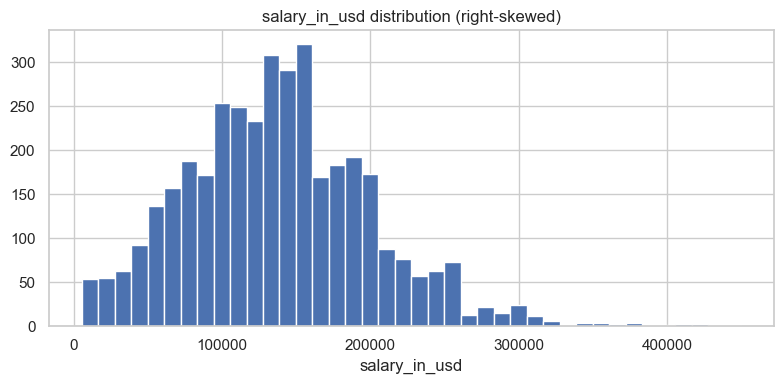

Skew=0.54. Outliers inflate RMSE; report MAE too.


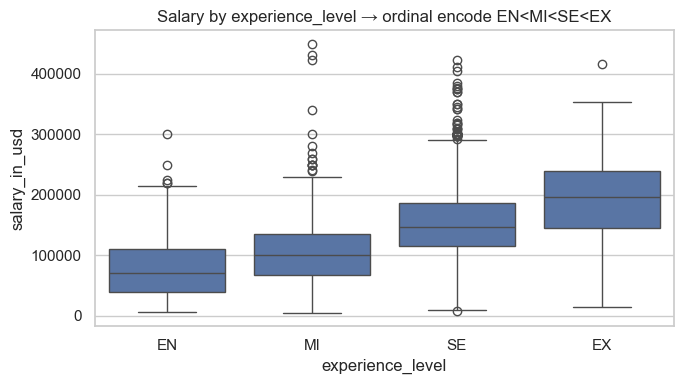

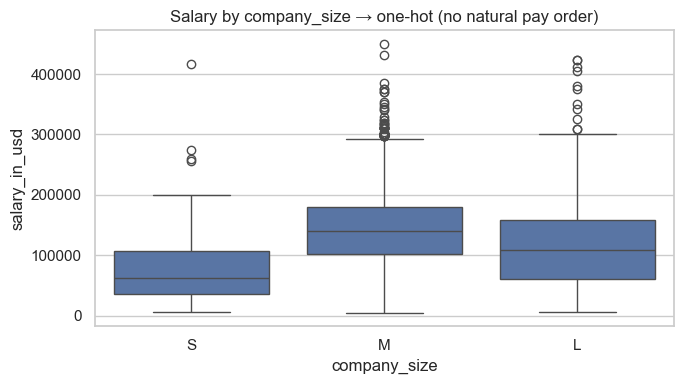

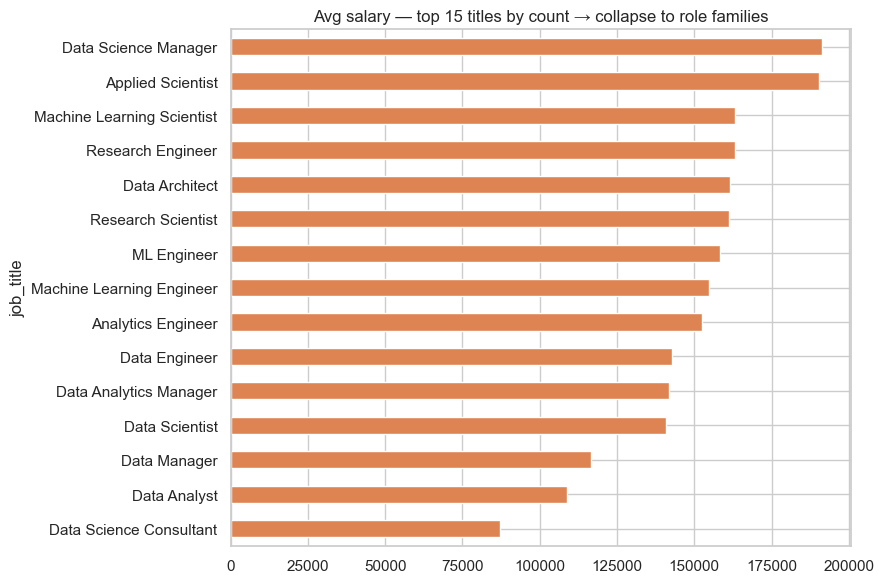

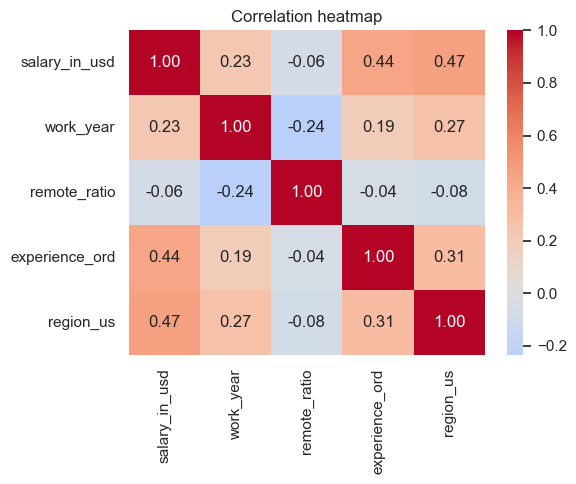

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["salary_in_usd"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("salary_in_usd distribution (right-skewed)")
ax.set_xlabel("salary_in_usd")
plt.tight_layout()
plt.show()
print(f"Skew={df['salary_in_usd'].skew():.2f}. Outliers inflate RMSE; report MAE too.")

order = ["EN", "MI", "SE", "EX"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="experience_level", y="salary_in_usd", order=order, ax=ax)
ax.set_title("Salary by experience_level → ordinal encode EN<MI<SE<EX")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="company_size", y="salary_in_usd", order=["S","M","L"], ax=ax)
ax.set_title("Salary by company_size → one-hot (no natural pay order)")
plt.tight_layout()
plt.show()

top15 = df["job_title"].value_counts().head(15).index
avg = df[df["job_title"].isin(top15)].groupby("job_title")["salary_in_usd"].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
avg.plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Avg salary — top 15 titles by count → collapse to role families")
plt.tight_layout()
plt.show()

enc = pd.DataFrame({
    "salary_in_usd": df["salary_in_usd"],
    "work_year": df["work_year"],
    "remote_ratio": df["remote_ratio"],
    "experience_ord": df["experience_level"].map(EXPERIENCE_ORDINAL),
    "region_us": (df["company_location"] == "US").astype(int),
})
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(enc.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap")
plt.tight_layout()
plt.show()

## 2. Feature engineering

Drop `salary` / `salary_currency` (leak target). Drop `employee_residence` (redundant; not an official predictor). Map job titles to families; ordinal experience; one-hot nominals; region buckets; StandardScaler fit on train only.

In [3]:
X, y = engineer_features(df)
print("Features:", list(X.columns))
print(X["job_family"].value_counts())
print(X["company_region"].value_counts())
print("Example mapping:", map_job_title_to_family("Data Science Manager"))

Features: ['work_year', 'experience_ord', 'remote_ratio', 'employment_type', 'company_size', 'job_family', 'company_region']
job_family
Data Engineer family     1329
Data Scientist family     909
Analyst family            676
ML/Research family        594
Leadership                198
Other                      49
Name: count, dtype: int64
company_region
US        3040
Europe     454
Other      164
Asia        97
Name: count, dtype: int64
Example mapping: Leadership


## 3. Train & compare: SGD vs LinearRegression vs DecisionTree vs RandomForest

SGD uses `partial_fit` with train/test loss curves. Best model by test R²/RMSE is saved for the API.

                       train_RMSE  train_R2   test_MAE  test_RMSE  test_R2
model                                                                     
SGDRegressor            49004.263     0.397  37911.857  48887.687    0.395
LinearRegression        48988.781     0.397  37907.729  48901.797    0.394
DecisionTreeRegressor   46000.048     0.468  37634.958  49407.467    0.382
RandomForestRegressor   43173.036     0.532  37250.949  48719.435    0.399


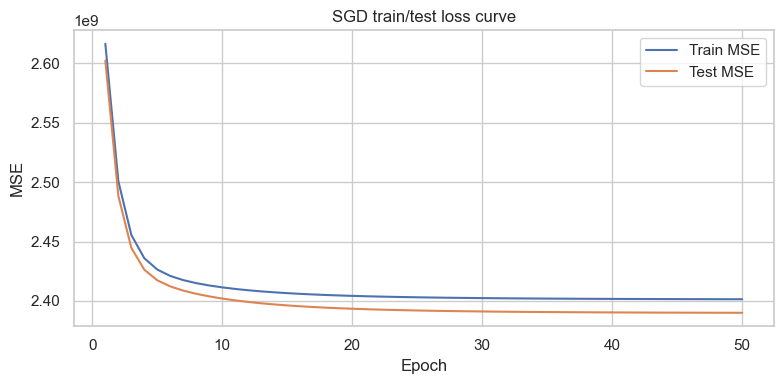

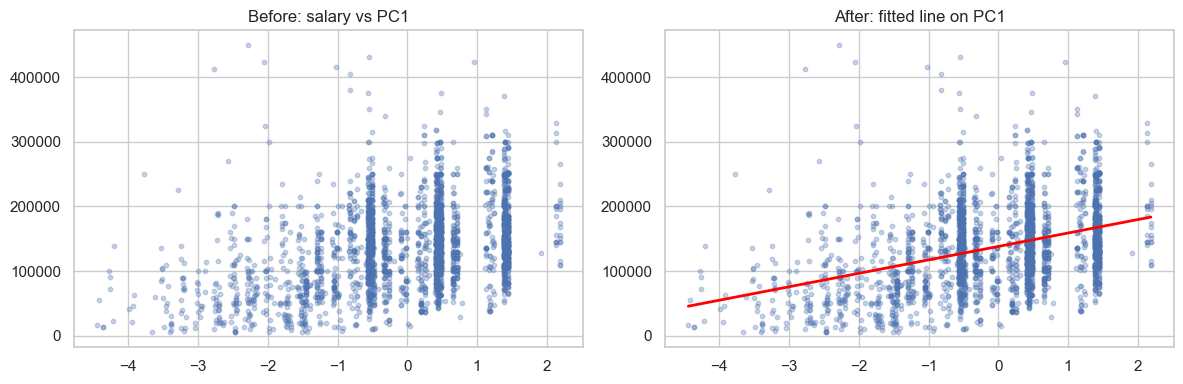

In [4]:
results = train_compare_models(X, y, sgd_alpha=1e-4, sgd_eta0=0.001, sgd_epochs=50)

rows = []
for name, m in results["metrics"].items():
    rows.append({
        "model": name,
        "train_RMSE": m["train"]["rmse"], "train_R2": m["train"]["r2"],
        "test_MAE": m["test"]["mae"], "test_RMSE": m["test"]["rmse"], "test_R2": m["test"]["r2"],
    })
metrics_df = pd.DataFrame(rows).set_index("model")
print(metrics_df.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
epochs = np.arange(1, len(results["sgd_train_losses"]) + 1)
ax.plot(epochs, results["sgd_train_losses"], label="Train MSE")
ax.plot(epochs, results["sgd_test_losses"], label="Test MSE")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE"); ax.set_title("SGD train/test loss curve")
ax.legend(); plt.tight_layout(); plt.show()

pca = PCA(n_components=1, random_state=42)
pc1 = pca.fit_transform(results["X_train_t"]).ravel()
y_tr = results["y_train"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pc1, y_tr, alpha=0.3, s=10)
axes[0].set_title("Before: salary vs PC1")
line = LinearRegression().fit(pc1.reshape(-1, 1), y_tr)
xs = np.linspace(pc1.min(), pc1.max(), 200)
axes[1].scatter(pc1, y_tr, alpha=0.3, s=10)
axes[1].plot(xs, line.predict(xs.reshape(-1, 1)), color="red", lw=2)
axes[1].set_title("After: fitted line on PC1")
plt.tight_layout(); plt.show()

## 4. Save best model and predict

In [5]:
summary = select_and_save_best(results, models_dir=MODELS_DIR)
print("Best:", summary["best_name"], summary["test_metrics"])

pred = predict_salary(
    experience_level="SE",
    employment_type="FT",
    job_title="Data Scientist",
    remote_ratio=50,
    company_size="M",
    company_location="US",
)
print(f"Example prediction: ${pred:,.0f}")

Best: RandomForestRegressor {'mae': 37250.94890822532, 'rmse': 48719.43463647315, 'r2': 0.39875641555457275}
Example prediction: $176,729
